In [1]:
!pip -q install requests beautifulsoup4 lxml pandas


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Fetch CVE dataset

In [2]:
%%sh
# Clone repository
if [ ! -d "cvelistV5" ]; then
    git clone https://github.com/CVEProject/cvelistV5.git
fi

# Create virtual environment if missing
if [ ! -d "cve-manipulation" ]; then
    python3 -m venv cve-manipulation
fi

. cve-manipulation/bin/activate

pip install --upgrade pip
pip install pandas numpy matplotlib wordcloud

## Fetch Intel and AMD advisory URLs using bs4

In [4]:
import re
from urllib.parse import urljoin
import os 
import requests
from bs4 import BeautifulSoup

URL = "https://www.intel.com/content/www/us/en/security-center/default.html"
BASE = "https://www.intel.com"

def fetch_html(url: str) -> str:
    r = requests.get(
        url,
        headers={"User-Agent": "intel-security-center-notebook/1.0"},
        timeout=30,
    )
    r.raise_for_status()
    return r.text

def extract_advisory_urls(html: str) -> list[str]:
    soup = BeautifulSoup(html, "lxml")

    # Preferred: table rows you referenced
    hrefs = [a["href"] for a in soup.select("tr.data td a[href]")]

    # Fallback: match any advisory links
    if not hrefs:
        pattern = re.compile(r"^/content/www/us/en/security-center/advisory/.*\.html$")
        hrefs = [a["href"] for a in soup.select("a[href]") if pattern.match(a["href"])]

    # Normalize + dedupe (keep order)
    out, seen = [], set()
    for h in hrefs:
        u = urljoin(BASE, h)
        if u not in seen:
            seen.add(u)
            out.append(u)
    return out

html = fetch_html(URL)
advisory_urls = extract_advisory_urls(html)

if not os.path.exists('../advisories/'):
    os.mkdir('../advisories')
    

with open("../advisories/intel-advisories.txt",'w') as f:
    for i in advisory_urls:
        f.write(i+'\n')

len(advisory_urls), advisory_urls[:10]

(989,
 ['https://www.intel.com/content/www/us/en/security-center/advisory/intel-sa-01393.html',
  'https://www.intel.com/content/www/us/en/security-center/advisory/intel-sa-01234.html',
  'https://www.intel.com/content/www/us/en/security-center/advisory/intel-sa-01415.html',
  'https://www.intel.com/content/www/us/en/security-center/advisory/intel-sa-01414.html',
  'https://www.intel.com/content/www/us/en/security-center/advisory/intel-sa-01412.html',
  'https://www.intel.com/content/www/us/en/security-center/advisory/intel-sa-01411.html',
  'https://www.intel.com/content/www/us/en/security-center/advisory/intel-sa-01408.html',
  'https://www.intel.com/content/www/us/en/security-center/advisory/intel-sa-01406.html',
  'https://www.intel.com/content/www/us/en/security-center/advisory/intel-sa-01403.html',
  'https://www.intel.com/content/www/us/en/security-center/advisory/intel-sa-01401.html'])

In [5]:
import re
from pathlib import Path
from urllib.parse import urljoin

import requests
from bs4 import BeautifulSoup

def write_amd_security_urls(
    out_path: str,
    page_url: str = "https://www.amd.com/en/resources/product-security.html#security",
) -> list[str]:
    """
    Fetch AMD product security page and write bulletin/brief URLs to a file.
    Returns the list of absolute URLs written.
    """
    base = "https://www.amd.com"

    session = requests.Session()
    session.headers.update({
        "User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0 Safari/537.36",
        "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
        "Accept-Language": "en-US,en;q=0.9",
    })

    r = session.get(page_url, timeout=30, allow_redirects=True)
    r.raise_for_status()

    soup = BeautifulSoup(r.text, "lxml")

    # Match typical AMD security bulletin/brief URL patterns
    pat = re.compile(r"^/en/resources/product-security/(bulletin|brief)/.*\.html$")

    hrefs = []
    for a in soup.select("a[href]"):
        h = (a.get("href") or "").strip()
        if pat.match(h):
            hrefs.append(urljoin(base, h))

    # Dedupe, preserve order
    seen, urls = set(), []
    for u in hrefs:
        if u not in seen:
            seen.add(u)
            urls.append(u)

    Path(out_path).write_text("\n".join(urls) + "\n", encoding="utf-8")
    return urls
amd_urls = write_amd_security_urls("../advisories/amd-advisories.txt")
len(amd_urls), amd_urls[:10]

(167,
 ['https://www.amd.com/en/resources/product-security/bulletin/amd-sb-7053.html',
  'https://www.amd.com/en/resources/product-security/bulletin/amd-sb-7050.html',
  'https://www.amd.com/en/resources/product-security/bulletin/amd-sb-3016.html',
  'https://www.amd.com/en/resources/product-security/bulletin/amd-sb-7060.html',
  'https://www.amd.com/en/resources/product-security/bulletin/amd-sb-7054.html',
  'https://www.amd.com/en/resources/product-security/bulletin/amd-sb-3023.html',
  'https://www.amd.com/en/resources/product-security/bulletin/amd-sb-3034.html',
  'https://www.amd.com/en/resources/product-security/bulletin/amd-sb-8010.html',
  'https://www.amd.com/en/resources/product-security/bulletin/amd-sb-3014.html',
  'https://www.amd.com/en/resources/product-security/bulletin/amd-sb-3027.html'])

 ## Compile SMM related regular expressions

In [2]:
import os
import json
import re

import pandas as pd

CVE_DIR="./cvelistV5/cves"
KEYWORDS=["system management mode",
          "System Management Mode", 
          "system-management-mode",
          "System-Management-Mode",
          "SMRAM","SMM","SMI handler",
          "system management ram","SMI transfer monitor","SMI callback"]
regex_str="|".join(KEYWORDS)
regex=re.compile(rf"\b({regex_str})\b", re.IGNORECASE)
smireg=re.compile(r"\bSMI\b", re.IGNORECASE)
smictx=re.compile(r"\b(BIOS|UEFI|firmware)\b",re.IGNORECASE)
# regex=re.compile(r"\b(system management mode|System Management Mode| system-management-mode|System-Management-Mode|SMRAM |SMM |system management ram)\b", re.IGNORECASE)


## Fetch each advisory URL found and check with the SMM related regular expressions

In [ ]:
import time
import random
import requests
session = requests.Session()
session.headers.update({
    "User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.9",
    "Accept-Encoding": "gzip, deflate, br",
    "Connection": "keep-alive",
    "Upgrade-Insecure-Requests": "1",
})
urls=[]
SLEEP=0.5
MAX_RETRIES=4
with open('../advisories/amd-advisories.txt','r') as fd:
    for line in fd:
        u=line.strip()
        if u:
            urls.append(u)
print(len(urls))
with open('../advisories/intel-advisories.txt','r') as fd:
    for line in fd:
        u=line.strip()
        if u:
            urls.append(u)

print(len(urls))

def fetch_with_retry(url, max_retries=MAX_RETRIES):
    backoff = 2.0
    for attempt in range(max_retries):
        try:
            r = session.get(url, timeout=30, allow_redirects=True)
        except requests.RequestException:
            if attempt == max_retries - 1:
                raise
            time.sleep(backoff + random.uniform(0, 0.5))
            backoff *= 2
            continue
        if r.status_code in (403, 429, 500, 502, 503, 504):
            if attempt == max_retries - 1:
                r.raise_for_status()
            time.sleep(backoff + random.uniform(0, 0.5))
            backoff *= 2
            continue
        r.raise_for_status()
        return r
    return r

matches=[]
failed=[]
for i,url in enumerate(urls):
    try:
        print(i,url)
        r=fetch_with_retry(url)
        text=r.text
        # get the url text and now use regex to search in it

        m = regex.search(text) or (smictx.search(text) and smireg.search(text) )
        # print(m)
        if m:
            matches.append((url,m))
    except Exception as e:
        print(f"Error {e} at {url}")
        failed.append(url)
        continue
    if SLEEP:
        time.sleep(SLEEP)

print(f"failed: {len(failed)}")
with open("../advisories/matches.txt",'w') as f:
    for i in matches:
        f.write(str(i[0])+'\n')
matches

167
1156
0 https://www.amd.com/en/resources/product-security/bulletin/amd-sb-7053.html
1 https://www.amd.com/en/resources/product-security/bulletin/amd-sb-7050.html
2 https://www.amd.com/en/resources/product-security/bulletin/amd-sb-3016.html
3 https://www.amd.com/en/resources/product-security/bulletin/amd-sb-7060.html
4 https://www.amd.com/en/resources/product-security/bulletin/amd-sb-7054.html
5 https://www.amd.com/en/resources/product-security/bulletin/amd-sb-3023.html
6 https://www.amd.com/en/resources/product-security/bulletin/amd-sb-3034.html
7 https://www.amd.com/en/resources/product-security/bulletin/amd-sb-8010.html
8 https://www.amd.com/en/resources/product-security/bulletin/amd-sb-3014.html
9 https://www.amd.com/en/resources/product-security/bulletin/amd-sb-3027.html
10 https://www.amd.com/en/resources/product-security/bulletin/amd-sb-7059.html
11 https://www.amd.com/en/resources/product-security/bulletin/amd-sb-6025.html
12 https://www.amd.com/en/resources/product-security/

## Find SMM related CVEs and related matched groups

In [11]:

import os
import json
import re

import pandas as pd

def is_smm_cve(full_path:os.path)->(re.Match|None):
    try:
        with open(full_path, "r", encoding="utf-8") as f:
            data = json.load(f)
    except Exception:
        return False  
    text = json.dumps(data)
    m = regex.search(text) or (smictx.search(text) and smireg.search(text) )
    if smireg.search(text) and smictx.search(text) and not regex.search(text):
        print(full_path)
        # m= smireg.search(text)
    # print(m)
    # if m is not None:
    #     print(m.group())
    return m

# Walk all directories recursively
smm_cve_matches=[]
matched_groups=[]
for root, dirs, files in os.walk(os.curdir):
    for filename in files:
        if filename.lower().endswith(".json") and filename.startswith("CVE-"):
            full_path = os.path.join(root, filename)
            m=is_smm_cve(full_path)
            if  m is not None:
                # print(full_path)
                # if m.group() == 'SMI':
                    # print(full_path)
                matched_groups.append(m.group())
                smm_cve_matches.append(full_path)

# print("\n=== SMM-RELATED CVEs FOUND ===")
# for m in smm_cve_matches:
#     print(m)

print(f"\nTotal: {len(smm_cve_matches)} CVEs")
print(f"Unique groups matched{set(matched_groups)}")



./cvelistV5/cves/2022/26xxx/CVE-2022-26858.json
./cvelistV5/cves/2022/34xxx/CVE-2022-34398.json
./cvelistV5/cves/2022/21xxx/CVE-2022-21933.json
./cvelistV5/cves/2022/3xxx/CVE-2022-3745.json
./cvelistV5/cves/2024/36xxx/CVE-2024-36877.json
./cvelistV5/cves/2023/28xxx/CVE-2023-28075.json
./cvelistV5/cves/2021/3xxx/CVE-2021-3843.json

Total: 316 CVEs
Unique groups matched{'system management mode', 'SMI transfer monitor', 'SMM', 'SMI Handler', 'SMRAM', 'smm', 'System Management Mode', 'SMI handler', 'SMI', 'SMI callback'}


## Extract fields from json cve data

In [12]:
from datetime import datetime
cve_data=[]
def parse_cve_json(cve_data:dict)->dict:
    dict_t={}
    dict_t['cveid']=cve_data['cveMetadata']['cveId']
    dict_t['assigner']=cve_data['cveMetadata']['assignerShortName']
    dict_t['datePublic']=str(datetime.fromisoformat(cve_data['cveMetadata']['datePublished']).year)
    dict_t['description']=cve_data['containers']['cna']['descriptions'][0]['value']
    # print(cve_data)
    if "problemTypes" in cve_data['containers']['cna'].keys():
        dict_t['problemtype']=str(cve_data['containers']['cna']['problemTypes'][0]['descriptions'][0]['description']).lower()
    else:
        dict_t['problemtype']="n/a"

    #[0]['descriptions'][0]['description']
    return dict_t

import re

def clean_text(s):
    if not isinstance(s, str):
        return ""
    s = s.lower()
    s = re.sub(r"[^a-z0-9\s\-]", " ", s)    # remove punctuation
    s = re.sub(r"\s+", " ", s).strip()      # collapse spaces
    return s

def clean_problem_type(pt):
    if not isinstance(pt, str):
        return ""
    pt = pt.lower()
    pt = pt.replace("cwe-", "")
    pt = re.sub(r"^\d+\s*", "", pt)  # remove number prefix
    pt = re.sub(r"[^a-z0-9\s-]", " ", pt)
    pt = re.sub(r"\s+", " ", pt).strip()
    return pt


    
for cve in smm_cve_matches:
    with open(cve,'r') as f:
       data=json.load(f) 
       cve_data.append(parse_cve_json(data))

dict_cves=json.dumps(cve_data)
df_smm_cves=pd.read_json(dict_cves)

df_smm_cves["pt_clean"] = df_smm_cves["problemtype"].apply(clean_problem_type)
df_smm_cves["clean_desc"] = df_smm_cves["description"].apply(clean_text)

df_smm_cves


/tmp/ipykernel_226233/2157334748.py:46: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df_smm_cves=pd.read_json(dict_cves)


,cveid,assigner,datePublic,description,problemtype,pt_clean,clean_desc
0,CVE-2025-7026,certcc,2025,A vulnerability in the Software SMI handler (S...,cwe-822 untrusted pointer dereference,untrusted pointer dereference,a vulnerability in the software smi handler sw...
1,CVE-2025-7029,certcc,2025,A vulnerability in the Software SMI handler (S...,cwe-822 uncontrolled pointer deference,uncontrolled pointer deference,a vulnerability in the software smi handler sw...
2,CVE-2025-7028,certcc,2025,A vulnerability in the Software SMI handler (S...,cwe-822 untrusted pointer dereference,untrusted pointer dereference,a vulnerability in the software smi handler sw...
3,CVE-2025-7027,certcc,2025,A vulnerability in the Software SMI handler (S...,cwe-822 untrusted pointer dereference,untrusted pointer dereference,a vulnerability in the software smi handler sw...
4,CVE-2025-31648,intel,2026,Improper handling of values in the microcode f...,escalation of privilege,escalation of privilege,improper handling of values in the microcode f...
...,...,...,...,...,...,...,...
311,CVE-2018-16092,lenovo,2018,In System Management Module (SMM) versions pri...,privilege escalation,privilege escalation,in system management module smm versions prior...
312,CVE-2018-12182,intel,2019,Insufficient memory write check in SMM service...,"escalation of privilege, information disclosur...",escalation of privilege information disclosure...,insufficient memory write check in smm service...
313,CVE-2018-3612,intel,2018,Intel NUC kits with insufficient input validat...,n/a,n a,intel nuc kits with insufficient input validat...
314,CVE-2015-0949,certcc,2020,The System Management Mode (SMM) implementatio...,other,other,the system management mode smm implementation ...


In [13]:
df_smm_cves['problemtype'].unique()

array(['cwe-822 untrusted pointer dereference',
       'cwe-822 uncontrolled pointer deference',
       'escalation of privilege',
       "cwe-79 improper neutralization of input during web page generation ('cross-site scripting')",
       'n/a',
       'cwe-1260  improper handling of overlap between protected memory ranges',
       'cwe-862 missing authorization',
       'cwe-693: protection mechanism failure',
       'cwe-119 improper restriction of operations within the bounds of a memory buffer',
       'cwe-20 improper input validation', 'cwe-787 out-of-bounds write',
       'cwe-200 exposure of sensitive information to an unauthorized actor',
       'cwe-121: stack-based buffer overflow',
       'cwe-1274  improper access control for volatile memory containing boot code',
       'cwe-123: write-what-where condition',
       'cwe-787: out-of-bounds write',
       'cwe-119: improper restriction of operations within the bounds of a memory buffer',
       'cwe-20: improper input vali

Empty DataFrame
Columns: [cveid, assigner, datePublic, description, problemtype, pt_clean, clean_desc]
Index: []
    datePublic  count
0         2006      1
1         2009      1
2         2010      1
3         2016      3
4         2017      1
5         2018     10
6         2019      8
7         2020     13
8         2021     17
9         2022     99
10        2023     85
11        2024     34
12        2025     37
13        2026      6


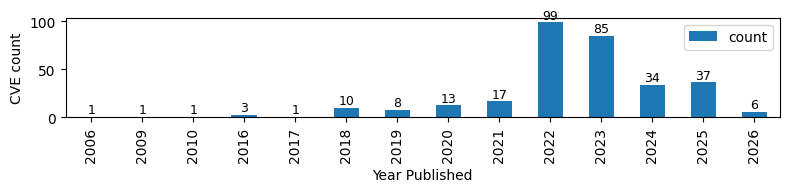

In [16]:

import matplotlib.pyplot as plt
print(df_smm_cves[df_smm_cves['datePublic']<2006])
df_per_year = df_smm_cves.groupby("datePublic").size().reset_index(name="count")
print(df_per_year)

ax = df_per_year.plot(
    kind="bar",
    x="datePublic",
    y="count",
    figsize=(8,2.0),
    xlabel="Year Published",
    ylabel="CVE count"
)

# Add count labels above each bar
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom', fontsize=9
    )
plt.savefig(
    "cve-plot.pdf",
    bbox_inches="tight",   # trims extra whitespace
    pad_inches=0.02,       # small padding
    dpi=300                # mainly affects rasterized elements; vector parts stay vector
)

plt.tight_layout()
plt.show()

In [33]:

print(df_smm_cves['problemtype'][df_smm_cves['datePublic']<2020])

148                                    denial of service
149                             arbitrary code execution
150                                                 none
151                             arbitrary code execution
152                               information disclosure
153                              escalation of privilege
154                               elevation of privilege
155                                                  n/a
156             microsoft device guard protection bypass
157                                   elevated privilege
158    execution of code in system management mode by...
191                                                  n/a
192                                                  n/a
303                                 privilege escalation
304                                 privilege escalation
305                                 privilege escalation
306                                 privilege escalation
307                            

## Analysis with custom classes, wordcloud and clustering

In [34]:
vuln_classes = {

    "Buffer and Memory Out-of-Bounds": [
        "heap-based buffer overflow",
        "cwe-122","cwe-121","cwe-120","cwe-119","cwe-125","cwe-787","cwe-788",
        "cwe-122: heap-based buffer overflow",
        "cwe-122 heap-based buffer overflow",
        "cwe-121: stack-based buffer overflow",
        "cwe-121 stack-based buffer overflow",
        "cwe-120 buffer copy without checking size of input ('classic buffer overflow')",
        "cwe-120 buffer overflow",
        "buffer overflow",
        "cwe-119 improper restriction of operations within the bounds of a memory buffer",
        "cwe-119: improper restriction of operations within the bounds of a memory buffer",
        "cwe-119 memory corruption - generic",
        "out-of-bounds read",
        "out-of-bounds write",
        "cwe-125 out-of-bounds read",
        "cwe-125: out-of-bounds read",
        "cwe-787 out-of-bounds write",
        "cwe-787: out-of-bounds write",
        "cwe-788: access of memory location after end of buffer"
    ],

    "Pointer Dereference Errors": [
        "cwe-822","cwe-476","cwe-825"
        "cwe-822 untrusted pointer dereference",
        "cwe-822 uncontrolled pointer dereference",
        "cwe-476 null pointer dereference",
        "null pointer dereference",
        "cwe-825: expired pointer dereference","null pointer deference"
    ],

    "Use-After-Free": [
        "cwe-416",
        "cwe-416 use after free",
        "cwe-416: use after free",
        "use-after-free",
        "use-after-free with smil animation controller",
        "use-after-free in smil animation functions",
        "use after free",
        "write-after-free"
    ],
    "Integer Overflow":["integer overflow", "cwe-191", "integer underflow",  "wrap or wraparound" ],

    "Access Control Authorization Failures": [
        "cwe-284 improper access control",
        "cwe-284 improper access control in smi handler",
        "cwe-284",
        "cwe-862 missing authorization",
        "cwe-264 permissions, privileges, and access controls",
        "cwe-1220 insufficient granularity of access control",
        "cwe-1220  insufficient granularity of access control",
        "cwe-281 improper preservation of permissions",
        "cwe-250 execution with unnecessary privileges",
        "cwe-288 authentication bypass using an alternate path or channel",
        "cwe-294 authentication bypass by capture-replay",
        "cwe-287: improper authentication",
        "cwe-306: missing authentication for critical function",
        "improper access control in core",
        "improper access control in kernel"
    ],

    "Input Validation": [
        "cwe-20 improper input validation",
        "cwe-20: improper input validation",
        "cwe-20",
        "cwe-79 improper neutralization of input during web page generation ('cross-site scripting')",
        "cwe-77: improper neutralization of special elements used in a command ('command injection')",
        "cwe-78: improper neutralization of special elements used in an os command ('os command injection')",
        "xxe injection vulnerability",
        "prototype pollution", "SMM callouts"
    ],

    "Cryptography & Sensitive Data Exposure": [
        "cwe-319 cleartext transmission of sensitive information",
        "cleartext transmission of sensitive information cwe-319",
        "cleartext transmission of sensitive data cwe-319",
        "cwe-327 - use of a broken or risky cryptographic algorithm",
        "cwe-347 improper verification of cryptographic signature",
        "cwe-200 exposure of sensitive information to an unauthorized actor",
        "information disclosure",
        "information exposure in kernel"
    ],

    "Privilege Escalation Bypass": [
        "escalation of privilege",
        "elevation of privilege",
        "elevated privilege",
        "privilege escalation",
        "escalation of privilege, information disclosure and/or denial of service",
        "microsoft device guard protection bypass"
    ],

    "Race Conditions & Concurrency": [
        "cwe-367: time-of-check time-of-use (toctou) race condition",
        "cwe-367 time-of-check time-of-use (toctou) race condition"
    ],

    "Resource Management Errors": [
        "cwe-457: use of uninitialized variable",
        "cwe-405: asymmetric resource consumption (amplification)",
        "cwe-835 loop with unreachable exit condition ('infinite loop')"
    ],

    "Configuration": [
        "configuration in buses.",
        "configuration issue in kernel",
        "inefficient algorithmic complexity",
        "cwe-754 improper adherence to coding standards",
        "cwe-130 improper handling of length parameter inconsistency",
        "cwe-642: external control of critical state data"
    ],

    "Hardware Access Control locking": [
        "cwe-1231 - improper prevention of lock bit modification",
        "cwe-1274 improper access control for volatile memory containing boot code"
    ],

    "Generic Attack Outcomes": [
        "denial of service",
        "arbitrary code execution",
        "buffer over-read in wlan"
    ],
    "Protection Mechanism Failure":["cwe-693: protection mechanism failure"]
    ,

    "Unknown": [
        "n/a",
        "none",
        "na",
        "unknown",
        "tbd",
    ]
}

In [35]:
import re

def extract_cwe(text):
    m = re.search(r'cwe[- ]?(\d+)', text, re.IGNORECASE)
    return f"cwe-{m.group(1)}" if m else None

vuln_classes_with_cwe_ids = {}

for cls, items in vuln_classes.items():
    new_list = []
    seen = set()
    
    for item in items:
        new_list.append(item)
        
        cwe = extract_cwe(item)
        if cwe and cwe not in seen:
            new_list.append(cwe)   # add the extracted CWE ID
            seen.add(cwe)
    
    vuln_classes_with_cwe_ids[cls] = new_list
vuln_classes=vuln_classes_with_cwe_ids
reverse_vuln_map = {
    pt: cls
    for cls, pts in vuln_classes.items()
    for pt in pts
}
reverse_vuln_map

{'heap-based buffer overflow': 'Buffer and Memory Out-of-Bounds',
 'cwe-122': 'Buffer and Memory Out-of-Bounds',
 'cwe-121': 'Buffer and Memory Out-of-Bounds',
 'cwe-120': 'Buffer and Memory Out-of-Bounds',
 'cwe-119': 'Buffer and Memory Out-of-Bounds',
 'cwe-125': 'Buffer and Memory Out-of-Bounds',
 'cwe-787': 'Buffer and Memory Out-of-Bounds',
 'cwe-788': 'Buffer and Memory Out-of-Bounds',
 'cwe-122: heap-based buffer overflow': 'Buffer and Memory Out-of-Bounds',
 'cwe-122 heap-based buffer overflow': 'Buffer and Memory Out-of-Bounds',
 'cwe-121: stack-based buffer overflow': 'Buffer and Memory Out-of-Bounds',
 'cwe-121 stack-based buffer overflow': 'Buffer and Memory Out-of-Bounds',
 "cwe-120 buffer copy without checking size of input ('classic buffer overflow')": 'Buffer and Memory Out-of-Bounds',
 'cwe-120 buffer overflow': 'Buffer and Memory Out-of-Bounds',
 'buffer overflow': 'Buffer and Memory Out-of-Bounds',
 'cwe-119 improper restriction of operations within the bounds of a m

In [36]:
import re

def classify_problem_type(pt, class_dict):
    pt_lower = pt.lower()

    for cls, patterns in class_dict.items():
        for p in patterns:
            p_lower = p.lower()

            # 1. direct substring match
            if p_lower in pt_lower or pt_lower in p_lower:
                return cls

            # 2. normalize by removing punctuation
            pt_norm = re.sub(r'[^a-z0-9]', ' ', pt_lower)
            p_norm  = re.sub(r'[^a-z0-9]', ' ', p_lower)

            if p_norm in pt_norm or pt_norm in p_norm:
                return cls

    return "Unknown"


In [37]:
df_smm_cves['problemClass']=df_smm_cves['problemtype'].apply(lambda pt: classify_problem_type(pt,vuln_classes))

In [38]:
df_smm_cves

,cveid,assigner,datePublic,description,problemtype,pt_clean,clean_desc,problemClass,cluster
0,CVE-2025-7026,certcc,2025,A vulnerability in the Software SMI handler (S...,cwe-822 untrusted pointer dereference,untrusted pointer dereference,a vulnerability in the software smi handler sw...,Pointer Dereference Errors,8
1,CVE-2025-7029,certcc,2025,A vulnerability in the Software SMI handler (S...,cwe-822 uncontrolled pointer deference,uncontrolled pointer deference,a vulnerability in the software smi handler sw...,Pointer Dereference Errors,0
2,CVE-2025-7028,certcc,2025,A vulnerability in the Software SMI handler (S...,cwe-822 untrusted pointer dereference,untrusted pointer dereference,a vulnerability in the software smi handler sw...,Pointer Dereference Errors,8
3,CVE-2025-7027,certcc,2025,A vulnerability in the Software SMI handler (S...,cwe-822 untrusted pointer dereference,untrusted pointer dereference,a vulnerability in the software smi handler sw...,Pointer Dereference Errors,8
4,CVE-2025-31648,intel,2026,Improper handling of values in the microcode f...,escalation of privilege,escalation of privilege,improper handling of values in the microcode f...,Privilege Escalation Bypass,3
...,...,...,...,...,...,...,...,...,...
311,CVE-2018-16092,lenovo,2018,In System Management Module (SMM) versions pri...,privilege escalation,privilege escalation,in system management module smm versions prior...,Privilege Escalation Bypass,3
312,CVE-2018-12182,intel,2019,Insufficient memory write check in SMM service...,"escalation of privilege, information disclosur...",escalation of privilege information disclosure...,insufficient memory write check in smm service...,Cryptography & Sensitive Data Exposure,0
313,CVE-2018-3612,intel,2018,Intel NUC kits with insufficient input validat...,n/a,n a,intel nuc kits with insufficient input validat...,Buffer and Memory Out-of-Bounds,0
314,CVE-2015-0949,certcc,2020,The System Management Mode (SMM) implementatio...,other,other,the system management mode smm implementation ...,Unknown,0


In [39]:
df_smm_cves["problemClass"].unique()

array(['Pointer Dereference Errors', 'Privilege Escalation Bypass',
       'Input Validation', 'Buffer and Memory Out-of-Bounds', 'Unknown',
       'Access Control Authorization Failures',
       'Protection Mechanism Failure', 'Hardware Access Control locking',
       'Race Conditions & Concurrency', 'Resource Management Errors',
       'Generic Attack Outcomes',
       'Cryptography & Sensitive Data Exposure', 'Configuration',
       'Use-After-Free'], dtype=object)

In [40]:
df_tmp=df_smm_cves[df_smm_cves['datePublic']>2018]
df_tmp['problemtype']

0                  cwe-822 untrusted pointer dereference
1                 cwe-822 uncontrolled pointer deference
2                  cwe-822 untrusted pointer dereference
3                  cwe-822 untrusted pointer dereference
4                                escalation of privilege
                             ...                        
300                                                  n/a
301                                                  n/a
302                                                  n/a
312    escalation of privilege, information disclosur...
314                                                other
Name: problemtype, Length: 299, dtype: object

In [41]:

df_unknown = df_smm_cves[df_smm_cves["problemClass"] == "Unknown"].copy()
df_unknown


,cveid,assigner,datePublic,description,problemtype,pt_clean,clean_desc,problemClass,cluster
7,CVE-2025-0012,AMD,2026,Improper handling of overlap between the segme...,cwe-1260 improper handling of overlap between...,improper handling of overlap between protected...,improper handling of overlap between the segme...,Unknown,0
22,CVE-2025-33045,AMI,2025,APTIOV contains vulnerabilities in the BIOS wh...,cwe-123: write-what-where condition,write-what-where condition,aptiov contains vulnerabilities in the bios wh...,Unknown,0
43,CVE-2022-26861,dell,2022,Dell BIOS versions contain an Insecure Automat...,cwe-1038: insecure automated optimizations,insecure automated optimizations,dell bios versions contain an insecure automat...,Unknown,0
56,CVE-2022-34399,dell,2023,\nDell Alienware m17 R5 BIOS version prior to ...,cwe-805: buffer access with incorrect length v...,buffer access with incorrect length value,dell alienware m17 r5 bios version prior to 1 ...,Unknown,0
77,CVE-2022-40262,certcc,2022,A potential attacker can execute an arbitrary ...,cwe-123 write-what-where condition,write-what-where condition,a potential attacker can execute an arbitrary ...,Unknown,0
81,CVE-2022-40246,certcc,2022,A potential attacker can write one byte by arb...,cwe-123 write-what-where condition,write-what-where condition,a potential attacker can write one byte by arb...,Unknown,0
150,CVE-2019-6156,lenovo,2019,"In Lenovo systems, SMM BIOS Write Protection i...",none,none,in lenovo systems smm bios write protection is...,Unknown,0
158,CVE-2017-3753,lenovo,2017,A vulnerability has been identified in some Le...,execution of code in system management mode by...,execution of code in system management mode by...,a vulnerability has been identified in some le...,Unknown,0
186,CVE-2024-36310,AMD,2026,Improper input validation in the SMM communica...,cwe-124 buffer underwrite ('buffer underflow'),buffer underwrite buffer underflow,improper input validation in the smm communica...,Unknown,0
241,CVE-2020-12951,AMD,2021,Race condition in ASP firmware could allow les...,tbd,tbd,race condition in asp firmware could allow les...,Unknown,0


In [42]:

df_per_assigner = df_smm_cves.groupby("assigner").size().reset_index(name="count")
print(df_per_assigner)

          assigner  count
0              AMD     38
1              AMI      8
2           Insyde      9
3            Linux      5
4       Patchstack      2
5          Phoenix      1
6   Samsung Mobile      1
7        TianoCore      1
8           certcc     10
9             dell     75
10              hp      1
11          huawei      5
12           intel      8
13          lenovo     55
14           mitre     92
15          nvidia      4
16          twcert      1


### Create Word cloud trends based on descriptions

In [43]:
%%sh
pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [44]:
from wordcloud import WordCloud,STOPWORDS
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

stopwords = set(STOPWORDS)


stopwords = {
    "vulnerability", "vulnerabilities", "attack", "attacker", "allows", "allow",
    "could", "may", "via", "also", "local", "an", "the", "and", "to", "in",
    "system", "management", "mode", "smm", "smi", "uefi", "firmware","arbitrary","kernel","code"
   , "issue","BIO","SMRAM",'user',"cause","execution","version","privilege","user","Dell","BIOS",'exploit'
    ,"function", "machine", "register", "software", "handler", "using", "used",
    "value", "values", "writes", "write", "memory",
    "potentially","lead","contain", "attackers","remote","remote attackers","dell","bios","of","cwe","a","improper","restriction", "of", "in", "to", "for", "by", "from", "with", "into", "on", "via",
"and", "or", "the", "a", "an","improper", "restriction", "within", "based", "condition", 
"operations", "access", "control", "information", "sensitive",
"transmission", "configuration", "consumption", "amplification"
 "cwe", "20", "119", "284", "319", "416", "787", "367","n"
    "cwe 20", "cwe 119", "cwe 284", "cwe 319", "cwe 416", "cwe 787", "cwe 367","n/a","n",
}

vectorizer = TfidfVectorizer(
    stop_words=list(stopwords),
    max_features=3000,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(df_smm_cves["pt_clean"].dropna().tolist())

/home/alouka/Documents/repos/smm-sok/paper/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['bio', 'ncwe', 'smram'] not in stop_words.
  warnings.warn(


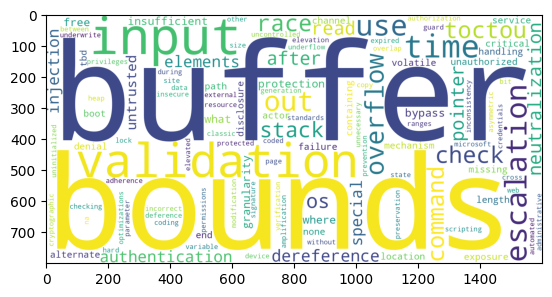

In [45]:

words = ' '.join(df_smm_cves['pt_clean'].dropna().tolist())
wc = WordCloud(
    width=1600,
    height=800,
    background_color="white",
    collocations=False,
    stopwords=stopwords
).generate(words)

plt.figure()
plt.imshow(wc)
plt.show()

In [46]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = {}
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X)
    scores[k] = silhouette_score(X, labels)
    

print(scores)
    

{2: 0.39743932753373706, 3: 0.5474148339085801, 4: 0.5773956248121724, 5: 0.6265331507078465, 6: 0.6638256018984799, 7: 0.6928852369154062, 8: 0.7047602463943536, 9: 0.7159707655589396}


In [47]:
k = 9  # or use your silhouette best value

model = KMeans(n_clusters=k, random_state=42)
df_smm_cves["cluster"] = model.fit_predict(X)

df_smm_cves

,cveid,assigner,datePublic,description,problemtype,pt_clean,clean_desc,problemClass,cluster
0,CVE-2025-7026,certcc,2025,A vulnerability in the Software SMI handler (S...,cwe-822 untrusted pointer dereference,untrusted pointer dereference,a vulnerability in the software smi handler sw...,Pointer Dereference Errors,8
1,CVE-2025-7029,certcc,2025,A vulnerability in the Software SMI handler (S...,cwe-822 uncontrolled pointer deference,uncontrolled pointer deference,a vulnerability in the software smi handler sw...,Pointer Dereference Errors,0
2,CVE-2025-7028,certcc,2025,A vulnerability in the Software SMI handler (S...,cwe-822 untrusted pointer dereference,untrusted pointer dereference,a vulnerability in the software smi handler sw...,Pointer Dereference Errors,8
3,CVE-2025-7027,certcc,2025,A vulnerability in the Software SMI handler (S...,cwe-822 untrusted pointer dereference,untrusted pointer dereference,a vulnerability in the software smi handler sw...,Pointer Dereference Errors,8
4,CVE-2025-31648,intel,2026,Improper handling of values in the microcode f...,escalation of privilege,escalation of privilege,improper handling of values in the microcode f...,Privilege Escalation Bypass,3
...,...,...,...,...,...,...,...,...,...
311,CVE-2018-16092,lenovo,2018,In System Management Module (SMM) versions pri...,privilege escalation,privilege escalation,in system management module smm versions prior...,Privilege Escalation Bypass,3
312,CVE-2018-12182,intel,2019,Insufficient memory write check in SMM service...,"escalation of privilege, information disclosur...",escalation of privilege information disclosure...,insufficient memory write check in smm service...,Cryptography & Sensitive Data Exposure,0
313,CVE-2018-3612,intel,2018,Intel NUC kits with insufficient input validat...,n/a,n a,intel nuc kits with insufficient input validat...,Buffer and Memory Out-of-Bounds,0
314,CVE-2015-0949,certcc,2020,The System Management Mode (SMM) implementatio...,other,other,the system management mode smm implementation ...,Unknown,0


In [48]:
import numpy as np

terms = vectorizer.get_feature_names_out()

def top_terms_for_cluster(model, terms, cluster_id, n=15):
    centroid = model.cluster_centers_[cluster_id]
    top_indices = centroid.argsort()[::-1][:n]
    return [terms[i] for i in top_indices]

for i in range(k):
    print(f"\n=== Cluster {i} ===")
    print(top_terms_for_cluster(model, terms, i))



=== Cluster 0 ===
['after', 'authentication', 'none', 'tbd', 'what', 'insufficient', 'what where', 'where', 'insufficient granularity', 'granularity', 'use', 'buffer', 'free', 'after free', 'use after']

=== Cluster 1 ===
['bounds buffer', 'bounds', 'buffer', 'without checking', 'what', 'without', 'where', 'what where', 'volatile', 'verification cryptographic', 'verification', 'variable', 'validation', 'use uninitialized', 'use toctou']

=== Cluster 2 ===
['validation', 'input validation', 'input', 'without checking', 'what', 'web page', 'where', 'without', 'volatile containing', 'volatile', 'verification', 'verification cryptographic', 'variable', 'use uninitialized', 'use toctou']

=== Cluster 3 ===
['escalation', 'without checking', 'where', 'without', 'what', 'web page', 'web', 'what where', 'volatile', 'verification cryptographic', 'verification', 'variable', 'validation', 'use uninitialized', 'use toctou']

=== Cluster 4 ===
['overflow', 'buffer overflow', 'stack buffer', 'stack